# 09. Playground and Test Judge Analysis

Analyze two phases separately: the playground contains all test-split documents from the author group of document 188; the final test phase excludes that author group. The split files remain unchanged. Results are tagged as `playground` or `test`, and summaries never pool playground judgments into the final test phase.

Assessment results use German prompt `0.5.0` and include candidate-aware aggregate gold segment summaries; feedback results use unchanged prompt `0.3.0`. Coverage may be partial while the playground is being calibrated or before final test judging. The notebook validates prompt, mode, author-group, teacher-reference, gold-summary, and input provenance. Treat all results as descriptive, not confirmatory.

In [1]:
import hashlib
import json
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from reflection_assessment_feedback.development_cohorts import (
    build_gold_segment_analysis_summary,
    load_author_document_group,
    load_remaining_test_feedback_cohort,
 )
from reflection_assessment_feedback.experiment_config import load_experiment_config
from reflection_assessment_feedback.llm_judge import (
    AssessmentQualityJudgeOutput,
    FeedbackQualityJudgeOutput,
    judge_input_sha256,
 )
from reflection_assessment_feedback.prompt_registry import resolve_prompt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != 'prebi_v1':
    raise RuntimeError('Run this notebook from the prebi_v1 project root.')
load_dotenv(PROJECT_ROOT / '.env', override=False)
protected_root_value = os.getenv('PREBI_DATA_ROOT')
if not protected_root_value:
    raise RuntimeError('Set PREBI_DATA_ROOT to approved protected storage.')
PROTECTED_ROOT = Path(protected_root_value).expanduser().resolve()
if PROTECTED_ROOT == PROJECT_ROOT or PROJECT_ROOT in PROTECTED_ROOT.parents:
    raise ValueError('PREBI_DATA_ROOT must be outside the project source tree.')

EXPERIMENT_CONFIG = load_experiment_config()
JUDGE_CONFIG = EXPERIMENT_CONFIG['llm_judge']
DATASET_CONFIG = EXPERIMENT_CONFIG['dataset']
PROMPTS = EXPERIMENT_CONFIG['prompts']
ASSESSMENT_PROMPT = resolve_prompt(PROMPTS['assessment_quality_llm_id'], PROMPTS['assessment_quality_llm_version'])
FEEDBACK_PROMPT = resolve_prompt(PROMPTS['feedback_quality_llm_id'], PROMPTS['feedback_quality_llm_version'])
SPLIT_PATH = (
    PROJECT_ROOT
    / EXPERIMENT_CONFIG['paths']['provisional_split_directory']
    / f"provisional_{DATASET_CONFIG['prediction_split']}_modeling_wide.csv"
 )
SPLIT_MANIFEST_PATH = (
    PROJECT_ROOT
    / EXPERIMENT_CONFIG['paths']['provisional_split_directory']
    / 'provisional_split_manifest.csv'
 )
PLAYGROUND_AUTHOR_DOCUMENTS = load_author_document_group(
    SPLIT_MANIFEST_PATH,
    DATASET_CONFIG['exploratory_document_id'],
 )
PLAYGROUND_DOCUMENT_IDS = set(PLAYGROUND_AUTHOR_DOCUMENTS['document_id'].astype(str))
PACKET_DIRECTORY = PROTECTED_ROOT / 'rating-packets' / 'development'
COHORT_SOURCES = [
    {
        'cohort_id': 'R1-development',
        'expected_documents': 6,
        'packet_path': PACKET_DIRECTORY / 'r1-rating-packets.json',
        'key_path': PACKET_DIRECTORY / 'r1-condition-key.json',
    },
    {
        'cohort_id': DATASET_CONFIG['generation_cohort'],
        'expected_documents': 16,
        'packet_path': PACKET_DIRECTORY / f"{DATASET_CONFIG['generation_cohort'].lower().replace('_', '-')}-rating-packets.json",
        'key_path': PACKET_DIRECTORY / f"{DATASET_CONFIG['generation_cohort'].lower().replace('_', '-')}-condition-key.json",
    },
]
JUDGE_RESULTS_ROOT = PROTECTED_ROOT / 'llm-judge' / 'development'
HUMAN_RATINGS_PATH = None
NEW_G2_SUMMARY_PATH = (
    PROJECT_ROOT / 'artifacts' / 'g2-author-disjoint-judge'
    / 'c9c3a10dfdd8756be0206e93e5025af7d3cd2629ed3a34397db88f6ebfdabf6a'
    / 'summary.json'
 )
print('Configured historical playground/test analysis and a separate new direct-GBERT G2 comparison.')

Configured historical playground/test analysis and a separate new direct-GBERT G2 comparison.


## 1. Load and validate results

Validate each saved result against the task-specific Pydantic schema, the current prompt/config fingerprint, and the packet-to-source key. Only structured scores and opaque join keys are retained for summaries; rationale text is not displayed.

In [2]:
if not JUDGE_RESULTS_ROOT.is_dir() or not JUDGE_RESULTS_ROOT.resolve().is_relative_to(PROTECTED_ROOT):
    raise FileNotFoundError('Protected judge result directory is unavailable.')

quality_packets = {}
key_by_packet = {}
teacher_reference_by_document = {}
teacher_reference_reflection_by_document = {}
gold_analysis_summary_by_document = {}
cohort_document_ids = {}
for cohort_source in COHORT_SOURCES:
    packet_path = cohort_source['packet_path']
    key_path = cohort_source['key_path']
    if not packet_path.is_file() or not key_path.is_file():
        raise FileNotFoundError(f"Missing protected packet/key export for {cohort_source['cohort_id']}.")
    packet_bundle = json.loads(packet_path.read_text(encoding='utf-8'))
    condition_key = json.loads(key_path.read_text(encoding='utf-8'))
    cohort_id = cohort_source['cohort_id']
    if condition_key.get('cohort') != cohort_id:
        raise ValueError('Packet key cohort differs from its configured source.')
    key_records = {row['packet_id']: row for row in condition_key.get('records', [])}
    cohort_packets = packet_bundle.get('packets', [])
    cohort_quality = {
        packet['packet_id']: packet
        for packet in cohort_packets
        if packet.get('task') in {'assessment_quality', 'feedback_quality'}
    }
    cohort_keys = {
        packet_id: row for packet_id, row in key_records.items()
        if row.get('task') in {'assessment_quality', 'feedback_quality'}
    }
    if set(cohort_quality) != set(cohort_keys):
        raise ValueError(f'Quality packet/key IDs differ for {cohort_id}.')
    if set(cohort_quality).intersection(quality_packets):
        raise ValueError('Packet IDs must be unique across cohorts.')

    references = {}
    reference_reflections = {}
    for reference_packet in cohort_packets:
        if reference_packet.get('task') != 'feedback_implied_score':
            continue
        reference_key = key_records.get(reference_packet.get('packet_id'))
        if reference_key is None:
            raise ValueError(f'A teacher-reference packet is missing its key for {cohort_id}.')
        document_id = str(reference_key['document_id'])
        reference_feedback = reference_packet.get('human_feedback')
        if not isinstance(reference_feedback, str) or not reference_feedback.strip():
            raise ValueError(f'A teacher-reference text is missing for {cohort_id}.')
        identity = (cohort_id, document_id)
        if identity in references:
            raise ValueError(f'Multiple teacher references found for one {cohort_id} document.')
        references[identity] = reference_feedback
        reference_reflections[identity] = reference_packet.get('displayed_reflection_sha256')

    document_ids = {str(row['document_id']) for row in cohort_keys.values()}
    if len(document_ids) != cohort_source['expected_documents']:
        raise ValueError(f'Quality packets do not cover the expected documents in {cohort_id}.')
    if {identity[1] for identity in references} != document_ids:
        raise ValueError(f'Teacher references do not cover exactly the quality documents in {cohort_id}.')

    reflection_by_document = {}
    for packet_id, packet in cohort_quality.items():
        key_record = cohort_keys[packet_id]
        document_id = str(key_record['document_id'])
        identity = (cohort_id, document_id)
        reflection_hash = packet.get('displayed_reflection_sha256')
        previous_hash = reflection_by_document.setdefault(document_id, reflection_hash)
        if previous_hash != reflection_hash:
            raise ValueError(f'Quality packets disagree on the reflection snapshot in {cohort_id}.')
        if reference_reflections[identity] != reflection_hash:
            raise ValueError(f'Teacher reference is attached to a different reflection in {cohort_id}.')
        if packet['task'] == 'assessment_quality':
            summary = build_gold_segment_analysis_summary(SPLIT_PATH, document_id)
            if summary['segment_count'] != len(packet['reflection'].get('segments', [])):
                raise ValueError('Gold-summary segment coverage differs from the rating packet.')
            gold_analysis_summary_by_document[identity] = summary
        quality_packets[packet_id] = packet
        key_by_packet[packet_id] = {**key_record, 'cohort_id': cohort_id}
    teacher_reference_by_document.update(references)
    teacher_reference_reflection_by_document.update(reference_reflections)
    cohort_document_ids[cohort_id] = document_ids

all_document_ids = set().union(*cohort_document_ids.values())
if not PLAYGROUND_DOCUMENT_IDS.issubset(all_document_ids):
    raise ValueError('Some playground author documents are missing quality packets.')
TEST_DOCUMENT_IDS = all_document_ids - PLAYGROUND_DOCUMENT_IDS
if len(PLAYGROUND_DOCUMENT_IDS) != 4 or len(TEST_DOCUMENT_IDS) != 18:
    raise ValueError('Playground/test split differs from the expected 4/18 document partition.')
phase_by_document = {
    document_id: ('playground' if document_id in PLAYGROUND_DOCUMENT_IDS else 'test')
    for document_id in all_document_ids
}

expected_prompts = {
    'assessment_quality': ASSESSMENT_PROMPT,
    'feedback_quality': FEEDBACK_PROMPT,
}
output_models = {
    'assessment_quality': AssessmentQualityJudgeOutput,
    'feedback_quality': FeedbackQualityJudgeOutput,
}
records = []
matched_results = {}
legacy_results_skipped = 0
for result_directory in sorted(path for path in JUDGE_RESULTS_ROOT.iterdir() if path.is_dir()):
    if not result_directory.resolve().is_relative_to(JUDGE_RESULTS_ROOT.resolve()):
        raise ValueError('A judge result directory resolves outside protected storage.')
    for result_path in sorted(result_directory.glob('judge-*.json')):
        record = json.loads(result_path.read_text(encoding='utf-8'))
        packet_id = record.get('packet_id')
        if packet_id not in quality_packets:
            continue
        packet = quality_packets[packet_id]
        key_record = key_by_packet[packet_id]
        task = packet['task']
        prompt = expected_prompts[task]
        document_id = str(key_record['document_id'])
        phase = phase_by_document[document_id]
        record_mode = record.get('evaluation_mode')
        if record_mode is None:
            legacy_results_skipped += 1
            continue
        if record_mode != phase:
            raise ValueError('Saved result evaluation mode does not match author-group membership.')
        judge_packet = {
            **packet,
            'reference_teacher_feedback': teacher_reference_by_document[
                (key_record['cohort_id'], document_id)
            ],
        }
        if task == 'assessment_quality':
            judge_packet['gold_analysis_summary'] = gold_analysis_summary_by_document[
                (key_record['cohort_id'], document_id)
            ]
        reference_sha256 = hashlib.sha256(
            judge_packet['reference_teacher_feedback'].encode('utf-8')
        ).hexdigest()
        if record.get('task') != task or record.get('record_type') != 'llm_judge_quality_rating':
            raise ValueError('Saved result task or record type does not match its packet.')
        if record.get('judge_provider') != JUDGE_CONFIG['provider'] or record.get('judge_model') != JUDGE_CONFIG['model_name']:
            raise ValueError('Saved result judge identity differs from current config.')
        if record.get('prompt_id') != prompt.artifact_id or record.get('prompt_version') != prompt.version:
            continue
        if record.get('prompt_artifact_sha256') != prompt.sha256:
            raise ValueError('Saved result prompt hash differs from the registered prompt.')
        if not record.get('experiment_config_sha256'):
            raise ValueError('Saved result is missing its config fingerprint.')
        if record.get('source_artifact_sha256') != key_record.get('source_artifact_sha256'):
            raise ValueError('Saved result source hash differs from its protected key.')
        if record.get('teacher_reference_sha256') != reference_sha256:
            raise ValueError('Saved result teacher-reference fingerprint differs from its packet.')
        if task == 'assessment_quality':
            summary_sha256 = hashlib.sha256(
                json.dumps(
                    judge_packet['gold_analysis_summary'],
                    ensure_ascii=False,
                    sort_keys=True,
                    separators=(',', ':'),
                ).encode('utf-8')
            ).hexdigest()
            if record.get('gold_analysis_summary_sha256') != summary_sha256:
                raise ValueError('Saved assessment result gold-summary fingerprint differs.')
        if record.get('input_packet_sha256') != judge_input_sha256(judge_packet):
            raise ValueError('Saved result input fingerprint differs from packet and judge context.')
        parsed_output = output_models[task].model_validate(record.get('result'))
        if packet_id in matched_results:
            raise ValueError('Multiple current-mode judge results exist for one packet.')
        matched_results[packet_id] = record
        for rating in parsed_output.ratings:
            records.append({
                'packet_id': packet_id,
                'phase': phase,
                'cohort': key_record['cohort_id'],
                'task': task,
                'document_id': document_id,
                'condition': key_record['condition'],
                'criterion_id': rating.criterion_id,
                'score': rating.score,
                'unable_to_judge': rating.unable_to_judge,
            })
if not records:
    raise ValueError('No current-mode judge results were found.')

scores = pd.DataFrame.from_records(records)
coverage = scores[['packet_id', 'phase', 'task', 'condition', 'document_id']].drop_duplicates()
expected_coverage = pd.MultiIndex.from_product(
    [['playground', 'test'], ['assessment_quality', 'feedback_quality'], ['G1', 'G2', 'G3']],
    names=['phase', 'task', 'condition'],
)
coverage_summary = (
    coverage.groupby(['phase', 'task', 'condition'])
    .agg(packet_count=('packet_id', 'nunique'), document_count=('document_id', 'nunique'))
    .reindex(expected_coverage, fill_value=0)
    .reset_index()
)
expected_assessment = {
    'playground': len(PLAYGROUND_DOCUMENT_IDS) * 3,
    'test': len(TEST_DOCUMENT_IDS) * 3,
}
observed_assessment = (
    scores.loc[scores['task'] == 'assessment_quality']
    .groupby('phase')['packet_id'].nunique().to_dict()
)
print(
    f"Validated {len(matched_results)} current-mode results; legacy untagged results skipped={legacy_results_skipped}. "
    f"Assessment coverage={observed_assessment}; expected by phase={expected_assessment}."
)
display(coverage_summary)

Validated 132 current-mode results; legacy untagged results skipped=132. Assessment coverage={'playground': 12, 'test': 54}; expected by phase={'playground': 12, 'test': 54}.


,phase,task,condition,packet_count,document_count
0,playground,assessment_quality,G1,4,4
1,playground,assessment_quality,G2,4,4
2,playground,assessment_quality,G3,4,4
3,playground,feedback_quality,G1,4,4
4,playground,feedback_quality,G2,4,4
5,playground,feedback_quality,G3,4,4
6,test,assessment_quality,G1,18,18
7,test,assessment_quality,G2,18,18
8,test,assessment_quality,G3,18,18
9,test,feedback_quality,G1,18,18


## 2. Phase-separated score summaries

Show scorable count, unable-to-judge count, mean/median, and 1–3 score counts separately for `playground` and `test`. Do not pool the playground author’s judgments into final test summaries. Partial phase coverage is shown rather than hidden.

,phase,task,condition,criterion_id,packet_count,unable_to_judge,mean_score,median_score,scorable_count,score_1_count,score_2_count,score_3_count
0,playground,assessment_quality,G1,evidence_support,4,0,2.75,3.0,4,0,1,3
1,playground,assessment_quality,G2,evidence_support,4,0,2.25,2.0,4,0,3,1
2,playground,assessment_quality,G3,evidence_support,4,0,2.75,3.0,4,0,1,3
3,playground,assessment_quality,G1,justification_quality,4,0,2.00,2.0,4,0,4,0
4,playground,assessment_quality,G2,justification_quality,4,0,2.00,2.0,4,0,4,0
5,playground,assessment_quality,G3,justification_quality,4,0,2.00,2.0,4,0,4,0
6,playground,assessment_quality,G1,score_rubric_fit,4,0,2.25,2.0,4,0,3,1
7,playground,assessment_quality,G2,score_rubric_fit,4,0,2.25,2.0,4,0,3,1
8,playground,assessment_quality,G3,score_rubric_fit,4,0,2.25,2.0,4,0,3,1
9,playground,feedback_quality,G1,correctness,4,0,2.75,3.0,4,0,1,3


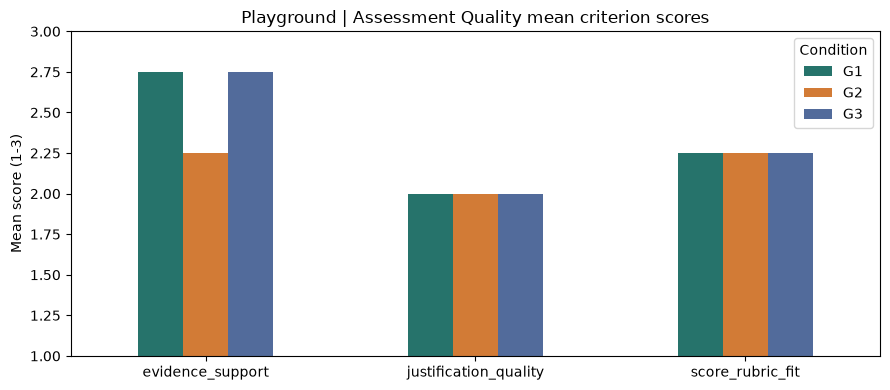

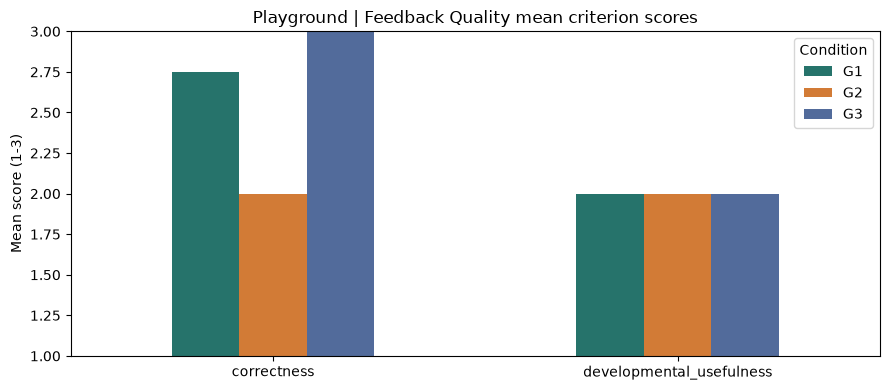

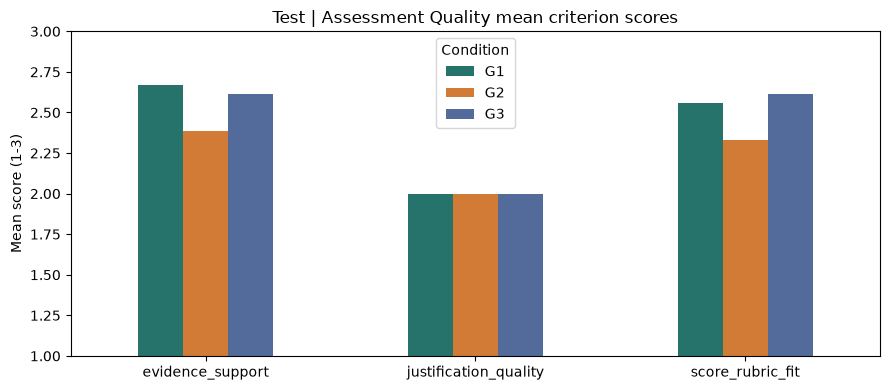

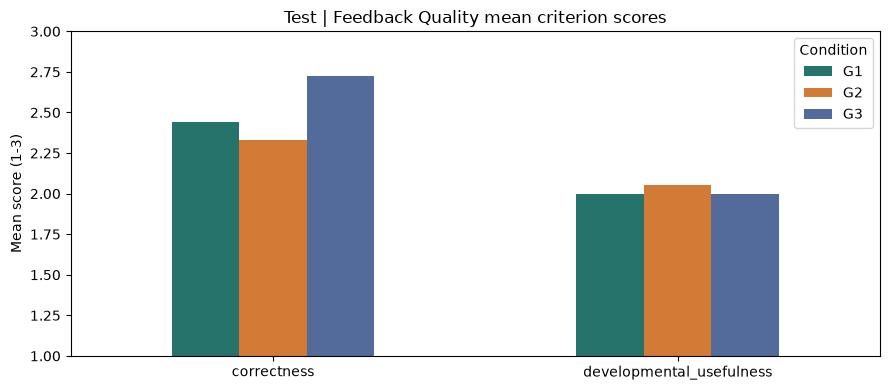

In [4]:
scored = scores.loc[scores['score'].notna()].copy()
summary = (
    scores.groupby(['phase', 'task', 'condition', 'criterion_id'], as_index=False)
    .agg(
        packet_count=('packet_id', 'nunique'),
        unable_to_judge=('unable_to_judge', 'sum'),
        mean_score=('score', 'mean'),
        median_score=('score', 'median'),
        scorable_count=('score', 'count'),
    )
)
for score_value in (1, 2, 3):
    frequency = (
        scored.assign(score_match=scored['score'].eq(score_value))
        .groupby(['phase', 'task', 'condition', 'criterion_id'])['score_match']
        .sum()
        .rename(f'score_{score_value}_count')
    )
    summary = summary.merge(
        frequency,
        on=['phase', 'task', 'condition', 'criterion_id'],
        how='left',
    )
frequency_columns = [f'score_{value}_count' for value in (1, 2, 3)]
summary[frequency_columns] = summary[frequency_columns].fillna(0).astype(int)
summary = summary.sort_values(['phase', 'task', 'criterion_id', 'condition']).reset_index(drop=True)
display(summary.round({'mean_score': 2, 'median_score': 2}))

import matplotlib.pyplot as plt

for phase in ('playground', 'test'):
    for task in ('assessment_quality', 'feedback_quality'):
        phase_task_data = summary.loc[
            summary['phase'].eq(phase) & summary['task'].eq(task)
        ]
        if phase_task_data.empty:
            continue
        pivot = phase_task_data.pivot(
            index='criterion_id', columns='condition', values='mean_score'
        )
        axis = pivot.plot(
            kind='bar', ylim=(1, 3), rot=0, figsize=(9, 4),
            color={'G1': '#26736b', 'G2': '#d27b36', 'G3': '#526b9b'},
        )
        axis.set_title(f'{phase.title()} | {task.replace("_", " ").title()} mean criterion scores')
        axis.set_ylabel('Mean score (1-3)')
        axis.set_xlabel('')
        axis.legend(title='Condition')
        plt.tight_layout()
        plt.show()

## 3. Matched descriptive differences

Compare G2 and G3 with G1 within each document, task, and criterion. The table reports paired difference distributions only and does not perform significance tests. A missing pair is reported by its available-pair count.

In [5]:
paired = scored.pivot_table(
    index=['phase', 'document_id', 'task', 'criterion_id'],
    columns='condition',
    values='score',
    aggfunc='first',
)
difference_frames = []
for comparator in ('G2', 'G3'):
    if comparator not in paired.columns or 'G1' not in paired.columns:
        continue
    pair_rows = paired[[comparator, 'G1']].dropna().reset_index()
    pair_rows['difference'] = pair_rows[comparator] - pair_rows['G1']
    if pair_rows.empty:
        continue
    pair_rows['comparator_vs_G1'] = f'{comparator} - G1'
    difference_frames.append(
        pair_rows[['phase', 'task', 'criterion_id', 'comparator_vs_G1', 'difference']]
    )
if difference_frames:
    differences = pd.concat(difference_frames, ignore_index=True)
    difference_summary = (
        differences.groupby(['phase', 'task', 'comparator_vs_G1', 'criterion_id'])['difference']
        .agg(paired_documents='count', mean_difference='mean', median_difference='median')
        .reset_index()
        .sort_values(['phase', 'task', 'criterion_id', 'comparator_vs_G1'])
    )
    display(difference_summary.round({'mean_difference': 2, 'median_difference': 2}))
else:
    print('No complete condition pairs are available yet.')

,phase,task,comparator_vs_G1,criterion_id,paired_documents,mean_difference,median_difference
0,playground,assessment_quality,G2 - G1,evidence_support,4,-0.50,-1.0
3,playground,assessment_quality,G3 - G1,evidence_support,4,0.00,0.0
1,playground,assessment_quality,G2 - G1,justification_quality,4,0.00,0.0
4,playground,assessment_quality,G3 - G1,justification_quality,4,0.00,0.0
2,playground,assessment_quality,G2 - G1,score_rubric_fit,4,0.00,0.0
5,playground,assessment_quality,G3 - G1,score_rubric_fit,4,0.00,0.0
6,playground,feedback_quality,G2 - G1,correctness,4,-0.75,-1.0
8,playground,feedback_quality,G3 - G1,correctness,4,0.25,0.0
7,playground,feedback_quality,G2 - G1,developmental_usefulness,4,0.00,0.0
9,playground,feedback_quality,G3 - G1,developmental_usefulness,4,0.00,0.0


## New G2: Author-Disjoint Direct GBERT Comparison

The new G2 batch uses direct GBERT trained on author-disjoint splits. Historical G1, G2, and G3 are retained as separate baselines. Comparisons match the 18 test documents, tasks, and criteria; the playground author and documents 218/221 are excluded. G1/G3 were not regenerated. These are descriptive comparisons, not a controlled estimate of the split correction or a significance test.

,task,documents,packets,criterion_ratings,unable_to_judge
0,assessment_quality,18,18,54,0
1,feedback_quality,18,18,36,0


condition                                    G1 historical  G2 historical  \
task               criterion_id                                             
assessment_quality evidence_support                  2.667          2.389   
                   justification_quality             2.000          2.000   
                   score_rubric_fit                  2.556          2.333   
feedback_quality   correctness                       2.444          2.333   
                   developmental_usefulness          2.000          2.056   

condition                                    G2 new direct GBERT  \
task               criterion_id                                    
assessment_quality evidence_support                        2.556   
                   justification_quality                   2.000   
                   score_rubric_fit                        2.333   
feedback_quality   correctness                             2.667   
                   developmental_usefulness                2.000   

condition                                    G3 historical  
task               criterion_id                             
assessment_quality evidence_support                  2.611  
                   justification_quality             2.000  
                   score_rubric_fit                  2.611  
feedback_quality   correctness                       2.722  
                   developmental_usefulness          2.000

,task,criterion_id,condition,document_count,mean_score,median_score,scorable_count,unable_to_judge
0,assessment_quality,evidence_support,G1 historical,18,2.667,3.0,18,0
1,assessment_quality,evidence_support,G2 historical,18,2.389,2.0,18,0
2,assessment_quality,evidence_support,G2 new direct GBERT,18,2.556,3.0,18,0
3,assessment_quality,evidence_support,G3 historical,18,2.611,3.0,18,0
4,assessment_quality,justification_quality,G1 historical,18,2.000,2.0,18,0
5,assessment_quality,justification_quality,G2 historical,18,2.000,2.0,18,0
6,assessment_quality,justification_quality,G2 new direct GBERT,18,2.000,2.0,18,0
7,assessment_quality,justification_quality,G3 historical,18,2.000,2.0,18,0
8,assessment_quality,score_rubric_fit,G1 historical,18,2.556,3.0,18,0
9,assessment_quality,score_rubric_fit,G2 historical,18,2.333,2.0,18,0


,task,criterion_id,comparison,paired_documents,mean_difference,median_difference,improved,unchanged,worsened
0,assessment_quality,evidence_support,G2 new direct GBERT - G1 historical,18,-0.111,0.0,4,8,6
1,assessment_quality,evidence_support,G2 new direct GBERT - G2 historical,18,0.167,0.0,6,9,3
2,assessment_quality,evidence_support,G2 new direct GBERT - G3 historical,18,-0.056,0.0,3,11,4
3,assessment_quality,justification_quality,G2 new direct GBERT - G1 historical,18,0.000,0.0,0,18,0
4,assessment_quality,justification_quality,G2 new direct GBERT - G2 historical,18,0.000,0.0,0,18,0
5,assessment_quality,justification_quality,G2 new direct GBERT - G3 historical,18,0.000,0.0,0,18,0
6,assessment_quality,score_rubric_fit,G2 new direct GBERT - G1 historical,18,-0.222,0.0,3,8,7
7,assessment_quality,score_rubric_fit,G2 new direct GBERT - G2 historical,18,0.000,0.0,2,14,2
8,assessment_quality,score_rubric_fit,G2 new direct GBERT - G3 historical,18,-0.278,0.0,3,7,8
9,feedback_quality,correctness,G2 new direct GBERT - G1 historical,18,0.222,0.0,7,8,3


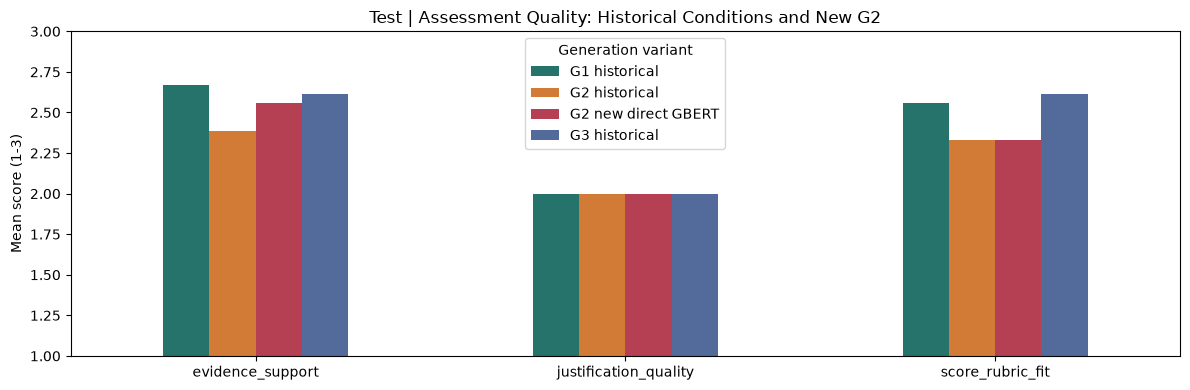

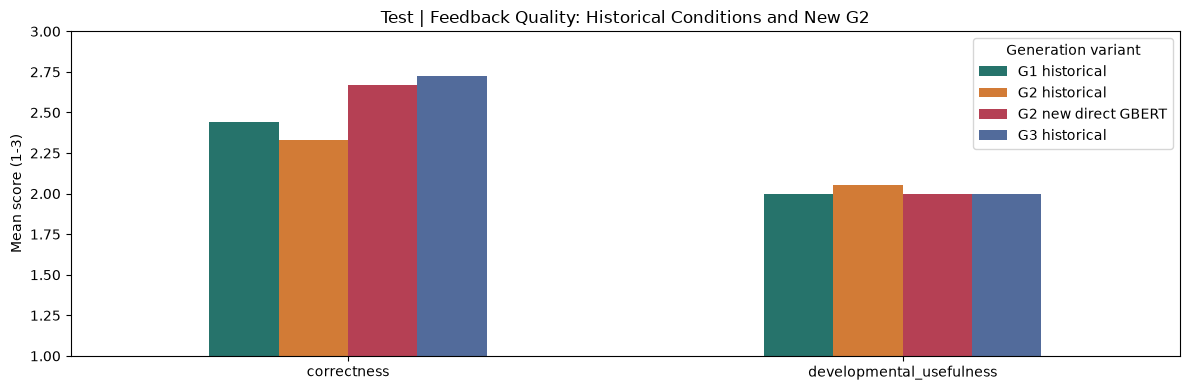

Validated new G2 against matched historical inputs; aggregate comparison CSVs saved beside its summary.


In [3]:
from IPython.display import Markdown, display
from reflection_assessment_feedback.judge_analysis import (
    NEW_G2_LABEL,
    compare_new_g2_scores,
    load_new_g2_judge_scores,
 )

display(Markdown('## New G2: Author-Disjoint Direct GBERT Comparison'))
display(Markdown(
    'The new G2 batch uses direct GBERT trained on author-disjoint splits. '
    'Historical G1, G2, and G3 are retained as separate baselines. '
    'Comparisons match the 18 test documents, tasks, and criteria; the playground author '
    'and documents 218/221 are excluded. G1/G3 were not regenerated. '
    'These are descriptive comparisons, not a controlled estimate of the split correction or a significance test.'
 ))

new_g2_scores, new_g2_packets = load_new_g2_judge_scores(
    NEW_G2_SUMMARY_PATH, PROTECTED_ROOT,
 )
configured_test_ids = set(load_remaining_test_feedback_cohort()['document_id'].astype(str))
if set(new_g2_scores['document_id']) != configured_test_ids or configured_test_ids != TEST_DOCUMENT_IDS:
    raise ValueError('Historical and new G2 test cohorts do not match the configured slice.')

new_packet_identities = (
    new_g2_scores[['packet_id', 'document_id', 'task']]
    .drop_duplicates()
 )
for identity in new_packet_identities.itertuples(index=False):
    new_packet = new_g2_packets[identity.packet_id]
    baseline_rows = scores.loc[
        scores['phase'].eq('test')
        & scores['document_id'].eq(identity.document_id)
        & scores['task'].eq(identity.task)
    ]
    for packet_id in baseline_rows['packet_id'].unique():
        historical_packet = quality_packets[packet_id]
        key_record = key_by_packet[packet_id]
        reference_identity = (key_record['cohort_id'], identity.document_id)
        if historical_packet['reflection'] != new_packet['reflection']:
            raise ValueError('Historical and new G2 reflection snapshots differ.')
        if historical_packet['rubric'] != new_packet['rubric']:
            raise ValueError('Historical and new G2 rubric snapshots differ.')
        if teacher_reference_by_document[reference_identity] != new_packet['reference_teacher_feedback']:
            raise ValueError('Historical and new G2 teacher references differ.')
        if identity.task == 'assessment_quality':
            if gold_analysis_summary_by_document[reference_identity] != new_packet['gold_analysis_summary']:
                raise ValueError('Historical and new G2 gold-summary contexts differ.')

new_g2_comparison_summary, new_g2_paired_differences = compare_new_g2_scores(
    scores, new_g2_scores,
 )
new_g2_coverage = new_g2_scores.groupby('task', as_index=False).agg(
    documents=('document_id', 'nunique'), packets=('packet_id', 'nunique'),
    criterion_ratings=('criterion_id', 'size'), unable_to_judge=('unable_to_judge', 'sum'),
 )
display(new_g2_coverage)
condition_order = ['G1 historical', 'G2 historical', NEW_G2_LABEL, 'G3 historical']
new_g2_mean_comparison = new_g2_comparison_summary.pivot(
    index=['task', 'criterion_id'], columns='condition', values='mean_score',
 ).reindex(columns=condition_order)
display(new_g2_mean_comparison.round(3))
display(new_g2_comparison_summary.round({'mean_score': 3, 'median_score': 3}))
display(new_g2_paired_differences.round({'mean_difference': 3, 'median_difference': 3}))

import matplotlib.pyplot as plt

for task in ('assessment_quality', 'feedback_quality'):
    plot_data = new_g2_mean_comparison.loc[task]
    axis = plot_data.plot(
        kind='bar', ylim=(1, 3), rot=0, figsize=(12, 4),
        color=['#26736b', '#d27b36', '#b54054', '#526b9b'],
    )
    axis.set_title(f'Test | {task.replace("_", " ").title()}: Historical Conditions and New G2')
    axis.set_ylabel('Mean score (1-3)')
    axis.set_xlabel('')
    axis.legend(title='Generation variant')
    plt.tight_layout()
    plt.show()

comparison_export_directory = NEW_G2_SUMMARY_PATH.parent
new_g2_comparison_summary.to_csv(
    comparison_export_directory / 'historical-comparison-summary.csv', index=False,
 )
new_g2_paired_differences.to_csv(
    comparison_export_directory / 'historical-comparison-paired-differences.csv', index=False,
 )
print('Validated new G2 against matched historical inputs; aggregate comparison CSVs saved beside its summary.')

## 4. Optional comparison with human ratings

Set `HUMAN_RATINGS_PATH` in Cell 2 to a protected rating UI JSON file or bundle. This section compares available human criterion scores with judge scores by packet and criterion using exact agreement and mean absolute difference. Unable-to-judge responses are counted separately and excluded from score agreement. These are descriptive agreement measures, not validation of either rater as ground truth.

In [5]:
if HUMAN_RATINGS_PATH is None:
    print('Human-rating comparison skipped; no protected UI export was configured.')
else:
    human_path = Path(HUMAN_RATINGS_PATH).expanduser().resolve()
    if not human_path.is_file():
        raise FileNotFoundError('Configured human-rating export was not found.')
    human_payload = json.loads(human_path.read_text(encoding='utf-8'))
    human_records = human_payload.get('ratings', []) if isinstance(human_payload, dict) else [human_payload]
    human_rows = []
    for human_record in human_records:
        if human_record.get('evaluator_type') != 'human':
            raise ValueError('The configured export contains a non-human rating record.')
        packet_id = human_record.get('packet_id')
        if packet_id not in quality_packets:
            continue
        packet = quality_packets[packet_id]
        if human_record.get('task') != packet['task']:
            raise ValueError('Human rating task does not match its packet.')
        key_record = key_by_packet[packet_id]
        document_id = str(key_record['document_id'])
        phase = 'playground' if document_id in PLAYGROUND_DOCUMENT_IDS else 'test'
        response = human_record.get('response', {})
        criterion_ratings = response.get('criterion_ratings', {})
        for criterion_id, answer in criterion_ratings.items():
            human_rows.append({
                'packet_id': packet_id,
                'phase': phase,
                'task': packet['task'],
                'criterion_id': criterion_id,
                'human_score': answer.get('score'),
                'human_unable_to_judge': bool(answer.get('unable_to_judge', False)),
            })
    human_scores = pd.DataFrame.from_records(human_rows)
    if human_scores.empty:
        print('No matching human quality ratings were found in the configured export.')
    else:
        judge_for_agreement = scores[
            ['packet_id', 'phase', 'task', 'criterion_id', 'score', 'unable_to_judge']
        ].rename(columns={'score': 'judge_score', 'unable_to_judge': 'judge_unable_to_judge'})
        agreement = human_scores.merge(
            judge_for_agreement,
            on=['packet_id', 'phase', 'task', 'criterion_id'],
            how='inner',
            validate='many_to_one',
        )
        agreement['absolute_difference'] = (agreement['human_score'] - agreement['judge_score']).abs()
        agreement['exact_agreement'] = agreement['human_score'].eq(agreement['judge_score'])
        agreement['both_scorable'] = (
            agreement['human_score'].notna()
            & agreement['judge_score'].notna()
            & ~agreement['human_unable_to_judge']
            & ~agreement['judge_unable_to_judge']
        )
        agreement_summary = (
            agreement.groupby(['phase', 'task', 'criterion_id'], as_index=False)
            .agg(
                matched_ratings=('packet_id', 'count'),
                human_unable_to_judge=('human_unable_to_judge', 'sum'),
                judge_unable_to_judge=('judge_unable_to_judge', 'sum'),
            )
        )
        scorable_agreement = agreement.loc[agreement['both_scorable']]
        score_agreement = (
            scorable_agreement.groupby(['phase', 'task', 'criterion_id'], as_index=False)
            .agg(
                exact_agreement=('exact_agreement', 'mean'),
                mean_absolute_difference=('absolute_difference', 'mean'),
                scorable_pairs=('packet_id', 'count'),
            )
        )
        agreement_summary = agreement_summary.merge(
            score_agreement,
            on=['phase', 'task', 'criterion_id'],
            how='left',
        )
        display(agreement_summary.round({'exact_agreement': 3, 'mean_absolute_difference': 2}))

Human-rating comparison skipped; no protected UI export was configured.


## 5. Export playground cases for protected review

The next cell creates a permission-restricted casebook outside the project tree. It contains the four playground reflections, matched teacher-educator feedback, and paired G1/G3 assessments and feedback. The cell prints only the protected file path and case count; do not move the casebook into the repository or share it through an unapproved channel.

In [10]:
import hashlib
import json
import os
import tempfile
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

from dotenv import load_dotenv
from reflection_assessment_feedback.development_cohorts import (
    GOLD_DIMENSIONS,
    GOLD_REVIEW_COLUMN,
    GOLD_SCOPE_COLUMN,
    GOLD_SCOPE_KNOWN_COLUMN,
    build_gold_segment_analysis_summary,
    load_author_document_group,
)
from reflection_assessment_feedback.experiment_config import load_experiment_config

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != 'prebi_v1':
    raise RuntimeError('Run this notebook from the prebi_v1 project root.')
load_dotenv(PROJECT_ROOT / '.env', override=False)
protected_root_value = os.getenv('PREBI_DATA_ROOT')
if not protected_root_value:
    raise RuntimeError('PREBI_DATA_ROOT must point to approved protected storage.')
PROTECTED_ROOT = Path(protected_root_value).expanduser().resolve()
if PROTECTED_ROOT == PROJECT_ROOT or PROJECT_ROOT in PROTECTED_ROOT.parents:
    raise ValueError('Protected casebooks must be outside the project source tree.')

config = load_experiment_config()
manifest_path = (
    PROJECT_ROOT
    / config['paths']['provisional_split_directory']
    / 'provisional_split_manifest.csv'
)
playground_documents = load_author_document_group(
    manifest_path,
    config['dataset']['exploratory_document_id'],
)
playground_document_ids = set(playground_documents['document_id'].astype(str))

split_rows = pd.read_csv(
    SPLIT_PATH,
    usecols=[
        'document_id', 'segment_id', 'candidate_id', 'segment_order',
        GOLD_SCOPE_COLUMN, GOLD_SCOPE_KNOWN_COLUMN, GOLD_REVIEW_COLUMN,
        *(column for pair in GOLD_DIMENSIONS.values() for column in pair),
    ],
    dtype=str,
)
split_rows['document_id'] = split_rows['document_id'].fillna('').str.strip()
split_rows = split_rows.loc[split_rows['document_id'].isin(playground_document_ids)].copy()

playground_sources = [
    source for source in COHORT_SOURCES
    if source['cohort_id'] == 'R1-development'
    or source['cohort_id'] == config['dataset']['generation_cohort']
]
teacher_feedback_by_document = {}
source_key_records = []
for source in playground_sources:
    bundle = json.loads(source['packet_path'].read_text(encoding='utf-8'))
    key_bundle = json.loads(source['key_path'].read_text(encoding='utf-8'))
    keys = {row['packet_id']: row for row in key_bundle.get('records', [])}
    packets = {packet['packet_id']: packet for packet in bundle.get('packets', [])}
    reference_packets = [
        packet for packet in packets.values()
        if packet.get('task') == 'feedback_implied_score'
    ]
    for reference_packet in reference_packets:
        reference_key = keys[reference_packet['packet_id']]
        document_id = str(reference_key['document_id'])
        if document_id not in playground_document_ids:
            continue
        reference_feedback = reference_packet.get('human_feedback')
        if not isinstance(reference_feedback, str) or not reference_feedback.strip():
            raise ValueError('A playground document is missing teacher-educator feedback.')
        if document_id in teacher_feedback_by_document:
            raise ValueError('Multiple teacher-feedback references found for a playground document.')
        teacher_feedback_by_document[document_id] = reference_feedback
        teacher_reflection_hash = reference_packet.get('displayed_reflection_sha256')
        for packet_id, packet in packets.items():
            key_record = keys[packet_id]
            if (
                str(key_record.get('document_id')) == document_id
                and key_record.get('task') in {'assessment_quality', 'feedback_quality'}
            ):
                if packet.get('displayed_reflection_sha256') != teacher_reflection_hash:
                    raise ValueError('Teacher feedback and rating packet refer to different reflection snapshots.')
                source_key_records.append((document_id, key_record['condition'], key_record))

if set(teacher_feedback_by_document) != playground_document_ids:
    raise ValueError('Teacher-feedback references do not cover the complete playground author group.')

comparison_directory = PROTECTED_ROOT / 'g1-g3' / 'demo-runs'
comparison_by_hash = {}
for comparison_path in comparison_directory.glob('comparison-*.json'):
    digest = hashlib.sha256(comparison_path.read_bytes()).hexdigest()
    comparison_by_hash[digest] = comparison_path

case_sections = [
    '# Playground casebook: author of exploratory document 188',
    '',
    'Protected research content. Keep this file in approved protected storage. It contains candidate-grain labels; competing candidates and unknowns are intentionally retained.',
]
for case_number, document_id in enumerate(sorted(playground_document_ids), start=1):
    document_rows = split_rows.loc[split_rows['document_id'] == document_id].copy()
    if document_rows.empty:
        raise ValueError('Gold labels are missing for a playground reflection.')
    document_rows['segment_order'] = pd.to_numeric(document_rows['segment_order'], errors='raise')
    gold_summary = build_gold_segment_analysis_summary(SPLIT_PATH, document_id)
    gold_segments = []
    for segment_id, candidates in document_rows.groupby('segment_id', sort=False):
        candidate_rows = []
        for _, row in candidates.iterrows():
            candidate_rows.append({
                'candidate_id': row['candidate_id'],
                'scope_target': row[GOLD_SCOPE_COLUMN],
                'scope_target_known': row[GOLD_SCOPE_KNOWN_COLUMN],
                'requires_review': row[GOLD_REVIEW_COLUMN],
                'component_bands': {
                    dimension: {
                        'target': row[target_column],
                        'known': row[known_column],
                    }
                    for dimension, (target_column, known_column) in GOLD_DIMENSIONS.items()
                },
            })
        gold_segments.append({
            'segment_id': segment_id,
            'segment_order': int(candidates['segment_order'].iloc[0]),
            'candidate_annotations': candidate_rows,
        })
    gold_segments.sort(key=lambda item: item['segment_order'])

    case_sections.extend([
        '',
        f'## Case {case_number} (document {document_id})',
        '',
        '### Reflection',
        '',
    ])
    assessment_packet = next(
        packet for packet in quality_packets.values()
        if packet.get('task') == 'assessment_quality'
        and str(key_by_packet[packet['packet_id']]['document_id']) == document_id
    )
    for segment in sorted(assessment_packet['reflection']['segments'], key=lambda item: item['order']):
        case_sections.extend([
            f"#### Segment {segment['order']}",
            '',
            segment['text'],
            '',
        ])
    case_sections.extend([
        '### Teacher-educator feedback',
        '',
        teacher_feedback_by_document[document_id],
        '',
        '### Gold analysis summary',
        '',
        'Aggregate counts are over candidate annotations; they are not a resolved segment-level gold label.',
        '',
        '```json',
        json.dumps(gold_summary, ensure_ascii=False, indent=2),
        '```',
        '',
        '### Gold candidate labels by segment',
        '',
        '```json',
        json.dumps(gold_segments, ensure_ascii=False, indent=2),
        '```',
        '',
    ])

    g2_assessment_packet = next(
        packet for packet in quality_packets.values()
        if packet.get('task') == 'assessment_quality'
        and str(key_by_packet[packet['packet_id']]['document_id']) == document_id
        and key_by_packet[packet['packet_id']].get('condition') == 'G2'
    )
    g2_feedback_packet = next(
        packet for packet in quality_packets.values()
        if packet.get('task') == 'feedback_quality'
        and str(key_by_packet[packet['packet_id']]['document_id']) == document_id
        and key_by_packet[packet['packet_id']].get('condition') == 'G2'
    )
    g2_output = {
        'assessment': g2_assessment_packet['output'],
        'feedback': g2_feedback_packet['output'],
    }
    case_sections.extend([
        '### G2 assessment and feedback',
        '',
        '```json',
        json.dumps(g2_output, ensure_ascii=False, indent=2),
        '```',
        '',
    ])

    for condition in ('G1', 'G3'):
        matching_keys = [
            record for source_document, source_condition, record in source_key_records
            if source_document == document_id and source_condition == condition
        ]
        if not matching_keys:
            raise ValueError(f'{condition} source key is missing for a playground document.')
        source_hashes = {record.get('source_artifact_sha256') for record in matching_keys}
        if len(source_hashes) != 1:
            raise ValueError(f'{condition} packets disagree on their comparison source artifact.')
        comparison_path = comparison_by_hash.get(next(iter(source_hashes)))
        if comparison_path is None:
            raise FileNotFoundError(f'{condition} comparison artifact is missing from protected storage.')
        comparison = json.loads(comparison_path.read_text(encoding='utf-8'))
        is_r1 = any(
            str(row['document_id']) == document_id and row.get('cohort_id') == 'R1-development'
            for row in key_by_packet.values()
        )
        expected_cohort = 'R1' if is_r1 else config['dataset']['generation_cohort']
        if comparison.get('document_id') != document_id or comparison.get('development_cohort') != expected_cohort:
            raise ValueError('Comparison artifact does not match the selected document/cohort.')
        run = comparison['pairs'][0].get(condition)
        if not run:
            raise ValueError(f'{condition} run is absent from its comparison artifact.')
        case_sections.extend([
            f'### {condition} assessment and feedback',
            '',
            '```json',
            json.dumps(run['output'], ensure_ascii=False, indent=2),
            '```',
            '',
        ])

casebook_directory = PROTECTED_ROOT / 'playground-review'
casebook_directory.mkdir(parents=True, exist_ok=True, mode=0o700)
os.chmod(casebook_directory, 0o700)
casebook_path = casebook_directory / (
    f"author-188-playground-{datetime.now(timezone.utc):%Y%m%dT%H%M%SZ}-{uuid4().hex[:8]}.md"
)
temporary_path = None
try:
    with tempfile.NamedTemporaryFile(
        mode='w', encoding='utf-8', dir=casebook_directory,
        prefix='.playground-casebook-', suffix='.tmp', delete=False,
    ) as temporary_file:
        temporary_path = Path(temporary_file.name)
        temporary_file.write('\n'.join(case_sections).rstrip() + '\n')
    os.chmod(temporary_path, 0o600)
    os.replace(temporary_path, casebook_path)
finally:
    if temporary_path is not None:
        temporary_path.unlink(missing_ok=True)
if not casebook_path.resolve().is_relative_to(PROTECTED_ROOT):
    raise ValueError('Playground casebook must resolve within PREBI_DATA_ROOT.')
print(f'Wrote protected playground casebook with reflection, gold labels/summary, and G1/G2/G3 outputs for {len(playground_document_ids)} documents: {casebook_path}')

Wrote protected playground casebook with reflection, gold labels/summary, and G1/G2/G3 outputs for 4 documents: /Users/quynguyen/Documents/CodingProjects/prebi_data/playground-review/author-188-playground-20261004T151713Z-fe91309e.md
